##### INF201 – Deliverable 1

##### Task 1: Temperature

In this task, we retrieve daily mean air temperature data for Ås
from the Norwegian Meteorological Institute (MET Norway) using
the Frost API.

The data covers the period from January 1st to December 31st, 2025.
The weather station used is SN17850, which is the weather station
for Ås.

In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
client_id = "b23154b4-6c95-42d8-a3c3-cbabf2aab02a"

In [12]:
endpoint = "https://frost.met.no/observations/v0.jsonld"

parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

response = requests.get(
    endpoint,
    params=parameters,
    auth=(client_id, "")
)

print(response.status_code)

200


In [13]:
data = response.json()

observations = data["data"]

print("Number of observations:", len(observations))

Number of observations: 364


In [14]:
temperature_data = []

for observation in observations:
    temperature_data.append({
        "time": observation["referenceTime"],
        "temperature": observation["observations"][0]["value"]
    })

temperature_df = pd.DataFrame(temperature_data)

temperature_df["time"] = pd.to_datetime(
    temperature_df["time"]
)

temperature_df.head()

,time,temperature
0,2025-01-01 00:00:00+00:00,-5.2
1,2025-01-02 00:00:00+00:00,-11.5
2,2025-01-03 00:00:00+00:00,-8.9
3,2025-01-04 00:00:00+00:00,-15.5
4,2025-01-05 00:00:00+00:00,-12.5


In [15]:
print(temperature_df.head())
print(temperature_df.tail())
print(temperature_df.shape)

                       time  temperature
0 2025-01-01 00:00:00+00:00         -5.2
1 2025-01-02 00:00:00+00:00        -11.5
2 2025-01-03 00:00:00+00:00         -8.9
3 2025-01-04 00:00:00+00:00        -15.5
4 2025-01-05 00:00:00+00:00        -12.5
                         time  temperature
359 2025-12-26 00:00:00+00:00         -2.9
360 2025-12-27 00:00:00+00:00         -0.6
361 2025-12-28 00:00:00+00:00         -4.6
362 2025-12-29 00:00:00+00:00         -3.6
363 2025-12-30 00:00:00+00:00         -3.0
(364, 2)


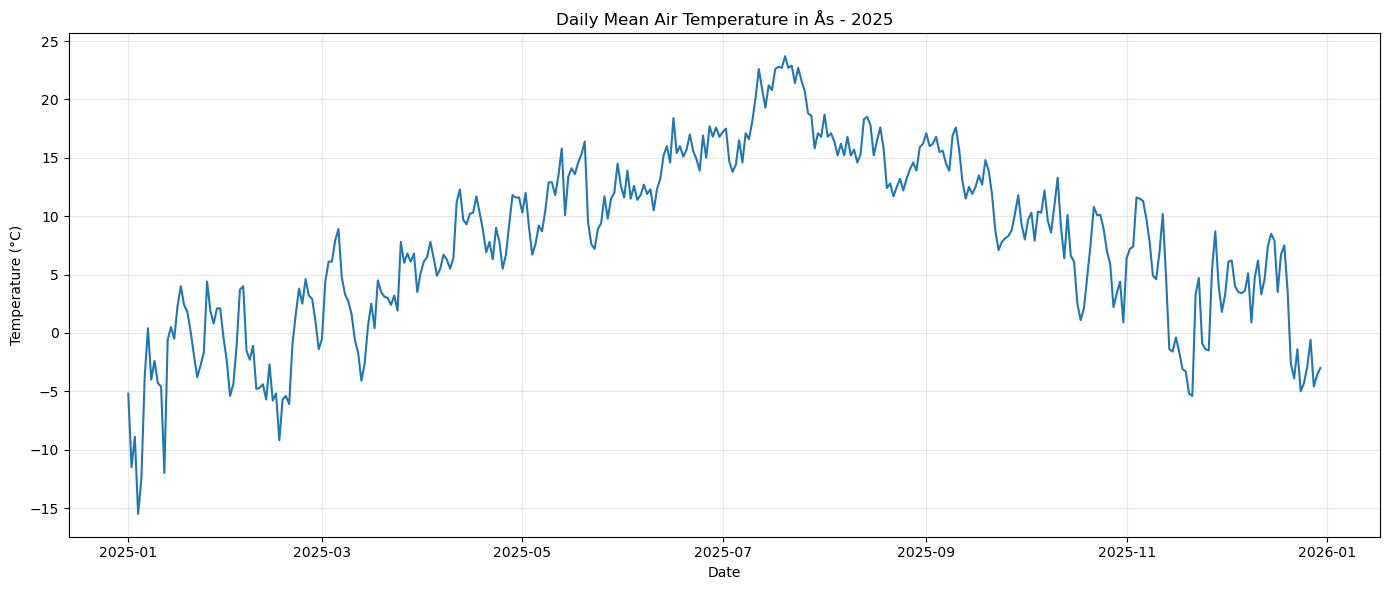

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    temperature_df["time"],
    temperature_df["temperature"],
    linewidth=1.5
)

plt.title("Daily Mean Air Temperature in Ås - 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
mean_temperature = temperature_df["temperature"].mean()
median_temperature = temperature_df["temperature"].median()
min_temperature = temperature_df["temperature"].min()
max_temperature = temperature_df["temperature"].max()

In [18]:
summary_table = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Temperature (°C)": [
        mean_temperature,
        median_temperature,
        min_temperature,
        max_temperature
    ]
})

In [19]:
summary_table["Temperature (°C)"] = (
    summary_table["Temperature (°C)"].round(2)
)

In [20]:
print(summary_table.to_string(index=False))

Statistic  Temperature (°C)
     Mean               7.9
   Median               8.4
  Minimum             -15.5
  Maximum              23.7


##### Task 2: Task 2 – Precipitation and temperature

In [21]:
# Request daily precipitation data

precipitation_parameters = {
    "sources": "SN17850",
    "elements": "sum(precipitation_amount P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

precipitation_response = requests.get(
    endpoint,
    params=precipitation_parameters,
    auth=(client_id, "")
)

print("API status code:", precipitation_response.status_code)

API status code: 200


In [31]:
#  Get daily precipitation for Ås in 2025 ---
precip_params = {
    "sources":       "SN17850",
    "elements":      "sum(precipitation_amount P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

precip_response = frost_get(precip_params)
precip_observations = precip_response["data"]

print("Number of daily precipitation observations:", len(precip_observations))

Number of daily precipitation observations: 364


We get daily precipitation from Frost using sum(precipitation_amount P1D) — which means "total precipitation per day". We get 364 days, same as for temperature. One day is missing, probably due to a sensor outage.

##### Importer pakker og last inn Client ID

In [ ]:
#  Imports og klient-ID ---
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Les klient-ID fra fil — ikke hardkodet
client_id = Path("client_id.txt").read_text().strip()
print("Klient-ID lastet:", client_id[:8] + "…")

# Endepunkt og hjelpefunksjon
endpoint = "https://frost.met.no/observations/v0.jsonld"

def frost_get(params):
    """Send GET til Frost. Returner {'data': []} ved HTTP 412."""
    r = requests.get(endpoint, params=params, auth=(client_id, ""))
    if r.status_code == 200:
        return r.json()
    if r.status_code == 412:
        return {"data": []}
    r.raise_for_status()

Klient-ID lastet: b23154b4…


##### Parse precipitation into a DataFrame

In [32]:
# --- Parse precipitation into DataFrame ---
precip_data = []
for obs in precip_observations:
    precip_data.append({
        "time":          pd.to_datetime(obs["referenceTime"]),
        "precipitation": obs["observations"][0]["value"],
    })

precipitation_df = pd.DataFrame(precip_data)
precipitation_df["time"] = pd.to_datetime(precipitation_df["time"])
precipitation_df = precipitation_df.set_index("time").sort_index()

print(precipitation_df.head())
print(f"Number of rows: {len(precipitation_df)}")
print(f"Missing values: {precipitation_df['precipitation'].isna().sum()}")
print(f"Days with 0 mm: {(precipitation_df['precipitation'] == 0).sum()}")
print(f"Max precipitation: {precipitation_df['precipitation'].max():.1f} mm")

                           precipitation
time                                    
2025-01-01 00:00:00+00:00            5.4
2025-01-02 00:00:00+00:00            0.0
2025-01-03 00:00:00+00:00            0.1
2025-01-04 00:00:00+00:00            0.0
2025-01-05 00:00:00+00:00            0.5
Number of rows: 364
Missing values: 0
Days with 0 mm: 180
Max precipitation: 36.1 mm


There are no missing values — all 364 days have a valid measurement. 180 days (about half) had zero precipitation. That is normal for Ås: most days are dry. The wettest day had 36.1 mm.

##### Combine temperature and precipitation

In [34]:
# --- Combine temperature and precipitation ---
combined_df = temperature_df.join(precipitation_df, how="outer").sort_index()

print(combined_df.head())
print(f"Shape: {combined_df.shape}")
print(f"Missing temperature: {combined_df['temperature'].isna().sum()}")
print(f"Missing precipitation: {combined_df['precipitation'].isna().sum()}")

                           temperature  precipitation
time                                                 
2025-01-01 00:00:00+00:00         -5.2            5.4
2025-01-02 00:00:00+00:00        -11.5            0.0
2025-01-03 00:00:00+00:00         -8.9            0.1
2025-01-04 00:00:00+00:00        -15.5            0.0
2025-01-05 00:00:00+00:00        -12.5            0.5
Shape: (364, 2)
Missing temperature: 0
Missing precipitation: 0


After combining, we have 364 rows and 2 columns — one for temperature and one for precipitation. No missing values means both series cover the same days. That is ideal for further analysis.

In [ ]:
# sett time som indeks på temperature_df ---
temperature_df = temperature_df.set_index("time").sort_index()

print(temperature_df.head())
print("Index:", temperature_df.index)
print("Columns:", temperature_df.columns)

                           temperature
time                                  
2025-01-01 00:00:00+00:00         -5.2
2025-01-02 00:00:00+00:00        -11.5
2025-01-03 00:00:00+00:00         -8.9
2025-01-04 00:00:00+00:00        -15.5
2025-01-05 00:00:00+00:00        -12.5
Index: DatetimeIndex(['2025-01-01 00:00:00+00:00', '2025-01-02 00:00:00+00:00',
               '2025-01-03 00:00:00+00:00', '2025-01-04 00:00:00+00:00',
               '2025-01-05 00:00:00+00:00', '2025-01-06 00:00:00+00:00',
               '2025-01-07 00:00:00+00:00', '2025-01-08 00:00:00+00:00',
               '2025-01-09 00:00:00+00:00', '2025-01-10 00:00:00+00:00',
               ...
               '2025-12-21 00:00:00+00:00', '2025-12-22 00:00:00+00:00',
               '2025-12-23 00:00:00+00:00', '2025-12-24 00:00:00+00:00',
               '2025-12-25 00:00:00+00:00', '2025-12-26 00:00:00+00:00',
               '2025-12-27 00:00:00+00:00', '2025-12-28 00:00:00+00:00',
               '2025-12-29 00:00:00+00:00', 

In [35]:
#  Slå sammen temperatur og nedbør ---
combined_df = temperature_df.join(precipitation_df, how="outer").sort_index()

print(combined_df.head())
print(f"\nShape: {combined_df.shape}")
print(f"Manglende temperatur: {combined_df['temperature'].isna().sum()}")
print(f"Manglende nedbør:     {combined_df['precipitation'].isna().sum()}")

                           temperature  precipitation
time                                                 
2025-01-01 00:00:00+00:00         -5.2            5.4
2025-01-02 00:00:00+00:00        -11.5            0.0
2025-01-03 00:00:00+00:00         -8.9            0.1
2025-01-04 00:00:00+00:00        -15.5            0.0
2025-01-05 00:00:00+00:00        -12.5            0.5

Shape: (364, 2)
Manglende temperatur: 0
Manglende nedbør:     0


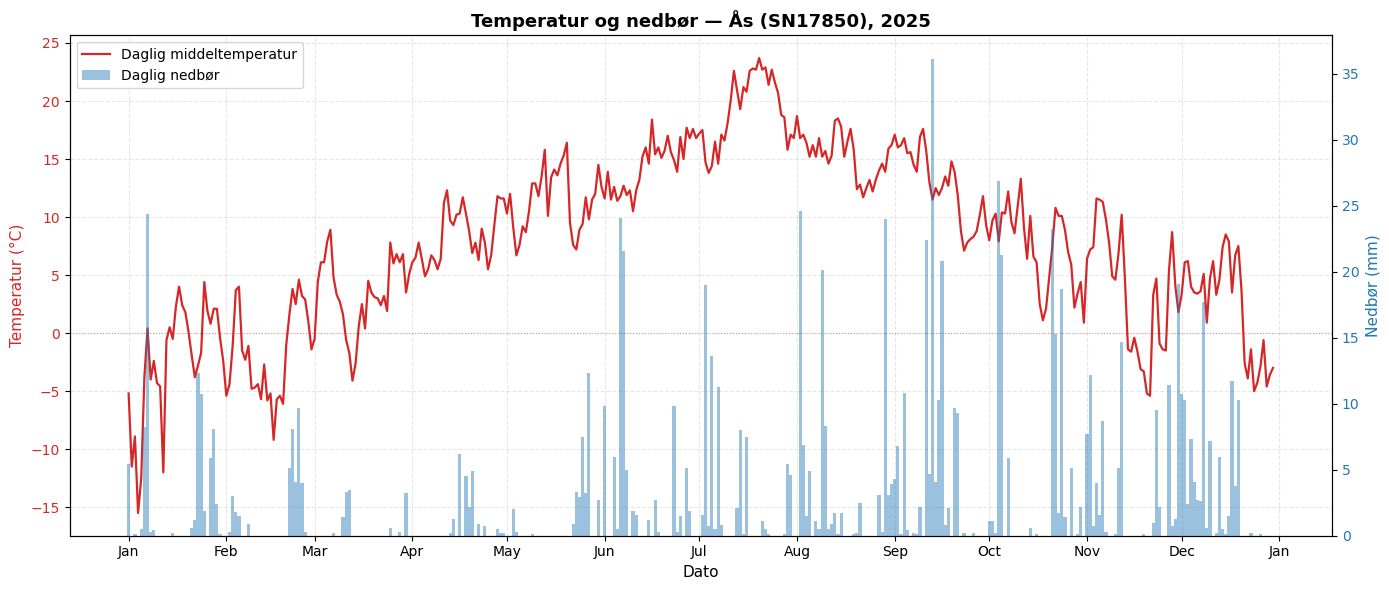

In [36]:
# Kombinert plott av temperatur og nedbør ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Venstre akse: temperatur (linje) ---
ax1.plot(
    combined_df.index,
    combined_df["temperature"],
    color="tab:red",
    linewidth=1.6,
    label="Daglig middeltemperatur",
)
ax1.set_xlabel("Dato", fontsize=11)
ax1.set_ylabel("Temperatur (°C)", color="tab:red", fontsize=11)
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.axhline(0, color="tab:red", linestyle=":", alpha=0.4, linewidth=0.8)

# --- Høyre akse: nedbør (stolper) ---
ax2 = ax1.twinx()
ax2.bar(
    combined_df.index,
    combined_df["precipitation"],
    color="tab:blue",
    alpha=0.45,
    width=1.0,
    label="Daglig nedbør",
)
ax2.set_ylabel("Nedbør (mm)", color="tab:blue", fontsize=11)
ax2.tick_params(axis="y", labelcolor="tab:blue")

# --- Formatering ---
ax1.set_title(
    "Temperatur og nedbør — Ås (SN17850), 2025",
    fontsize=13, fontweight="bold",
)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.grid(alpha=0.3, linestyle="--")

# --- Felles legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("task2_temperature_precipitation_2025.png", dpi=150)
plt.show()

I use a line for temperature because it is a smooth quantity that changes continuously. I use bars for precipitation because precipitation comes in individual events — some days have a lot, most days have none. The bars make it easy to see which days it rained.

I use two y-axes because temperature and precipitation have different units (°C and mm) and different scales. If they shared one axis, one of the series would become unreadable.

In [29]:
print(precipitation_df.head())
print("Index:", precipitation_df.index)
print("Columns:", precipitation_df.columns)
print()
print(combined_df.head())
print(f"Shape: {combined_df.shape}")
print(f"Missing temp: {combined_df['temperature'].isna().sum()}")
print(f"Missing precip: {combined_df['precipitation'].isna().sum()}")

                           precipitation
time                                    
2025-01-01 00:00:00+00:00            5.4
2025-01-02 00:00:00+00:00            0.0
2025-01-03 00:00:00+00:00            0.1
2025-01-04 00:00:00+00:00            0.0
2025-01-05 00:00:00+00:00            0.5
Index: DatetimeIndex(['2025-01-01 00:00:00+00:00', '2025-01-02 00:00:00+00:00',
               '2025-01-03 00:00:00+00:00', '2025-01-04 00:00:00+00:00',
               '2025-01-05 00:00:00+00:00', '2025-01-06 00:00:00+00:00',
               '2025-01-07 00:00:00+00:00', '2025-01-08 00:00:00+00:00',
               '2025-01-09 00:00:00+00:00', '2025-01-10 00:00:00+00:00',
               ...
               '2025-12-21 00:00:00+00:00', '2025-12-22 00:00:00+00:00',
               '2025-12-23 00:00:00+00:00', '2025-12-24 00:00:00+00:00',
               '2025-12-25 00:00:00+00:00', '2025-12-26 00:00:00+00:00',
               '2025-12-27 00:00:00+00:00', '2025-12-28 00:00:00+00:00',
               '2025-12-29 00:

##### Summery Discussion 

The precipitation data has 364 days for Ås (SN17850) in 2025. There are
no missing values. 180 days had 0 mm of precipitation, and the wettest
day had 36.1 mm.

**Why two y-axes?**
Temperature is measured in °C, precipitation in mm. They have different
scales, so they need separate axes to be readable in the same plot.

**Why a line for temperature?**
Temperature is a smooth quantity that changes continuously throughout
the year. A line shows this development clearly.

**Why bars for precipitation?**
Precipitation comes in individual events. Most days are dry, some days
have a lot of rain. Bars mark these events clearly.

**What do we see in the plot?**
Temperature follows a clear season: cold winter, warm summer.
Precipitation does not follow the same pattern — it is more randomly
distributed throughout the year. There is no clear relationship between
temperature and precipitation on a daily basis.

**Missing day:**
One day is missing (364 of 365 days). We have not filled in any value
for the missing day, because we do not know whether it rained or not.

**Reference:**
The code is adapted from MET's Frost example at
https://frost.met.no/howto.html.